# 01 - Kiểm tra dữ liệu
Chạy `src/download_data.py` và `src/preprocessing.py` trước, sau đó dùng notebook này để kiểm tra chất lượng dữ liệu trước khi phân tích.

## Mục tiêu

1. Kiểm tra cấu trúc và khoảng thời gian của dữ liệu.
2. Kiểm tra missing values và duplicate dates.
3. Kiểm tra tính liên tục của dữ liệu CRV 24/7.
4. Thống kê mô tả giá CRV và S&P 500.
5. Tính simple return và log return.
6. Quan sát trực quan biến động giá và return.
7. Kiểm tra dữ liệu xung quanh sự kiện Curve Finance exploit ngày 30/07/2023.
8. Đánh giá sơ bộ dữ liệu có phù hợp để tiếp tục phân tích ACF/ADF hay không.

### Nguyên tắc sử dụng dữ liệu

- CRV sử dụng dataset đầy đủ 24/7 để phân tích chuỗi thời gian của chính CRV.
- S&P 500 được sử dụng làm benchmark.
- Khi so sánh CRV với S&P 500, chỉ sử dụng những ngày cả hai thị trường đều có dữ liệu.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [44]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

PLOTS_DIR = PROCESSED_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT ROOT:")
print(PROJECT_ROOT)

print("\nProcessed data:")
print(PROCESSED_DIR)

PROJECT ROOT:
d:\Workspace\Trí tuệ DN\crypto_non_stationarity

Processed data:
d:\Workspace\Trí tuệ DN\crypto_non_stationarity\data\processed


In [45]:
crv_path = PROCESSED_DIR / "crv_full_2021_2024.csv"

crv = pd.read_csv(
    crv_path,
    parse_dates=["Date"]
)

crv = crv.sort_values("Date").reset_index(drop=True)

print(f"Số dòng: {len(crv):,}")
print(f"Số cột: {len(crv.columns)}")

crv.head()

Số dòng: 1,461
Số cột: 8


,Date,Open,High,Low,CRV_Close,CRV_Volume,CRV_simple_return,CRV_log_return
0,2021-01-01,0.627502,0.672054,0.609296,0.622334,64874778,NaN,NaN
1,2021-01-02,0.623145,0.623501,0.568533,0.614176,60722245,-0.013109,-0.013195
2,2021-01-03,0.614083,0.690932,0.589104,0.672281,68729992,0.094607,0.090395
3,2021-01-04,0.675712,0.727619,0.583590,0.676984,95367065,0.006996,0.006971
4,2021-01-05,0.677240,0.724537,0.627403,0.687015,82062825,0.014817,0.014708


**Cấu trúc CRV**

In [46]:
crv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1461 non-null   datetime64[ns]
 1   Open               1461 non-null   float64       
 2   High               1461 non-null   float64       
 3   Low                1461 non-null   float64       
 4   CRV_Close          1461 non-null   float64       
 5   CRV_Volume         1461 non-null   int64         
 6   CRV_simple_return  1460 non-null   float64       
 7   CRV_log_return     1460 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 91.4 KB


In [47]:
crv.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1461,2023-01-01 00:00:00.000000256,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,2024-01-01 00:00:00,2024-12-31 00:00:00,NaN
Open,"1,461.000000",1.391645,0.209619,0.541141,0.905952,2.104748,6.505204,1.191980
High,"1,461.000000",1.470091,0.233181,0.554914,0.939178,2.250617,6.743056,1.275642
Low,"1,461.000000",1.313555,0.181093,0.521531,0.876997,1.991230,6.067784,1.111612
CRV_Close,"1,461.000000",1.391096,0.209620,0.541141,0.905959,2.104662,6.503538,1.189285
CRV_Volume,"1,461.000000","177,331,597.278576","13,626,736.000000","53,528,104.000000","107,159,911.000000","223,994,168.000000","1,619,119,461.000000","197,389,925.272605"
CRV_simple_return,"1,460.000000",0.002659,-0.433753,-0.033960,-0.001374,0.033630,0.522000,0.070009
CRV_log_return,"1,460.000000",0.000248,-0.568725,-0.034550,-0.001375,0.033077,0.420025,0.069406


**Kiểm tra khoảng thời gian**

In [48]:
print("Ngày bắt đầu:", crv["Date"].min().date())
print("Ngày kết thúc:", crv["Date"].max().date())

print("\nSố ngày unique:", crv["Date"].nunique())
print("Số dòng:", len(crv))

Ngày bắt đầu: 2021-01-01
Ngày kết thúc: 2024-12-31

Số ngày unique: 1461
Số dòng: 1461


**Kiểm tra Dulicate Date**

In [49]:
duplicate_count = crv["Date"].duplicated().sum()

print(f"Duplicate Date: {duplicate_count}")

Duplicate Date: 0


**Kiểm tra Missing Data**

In [50]:
missing = crv.isna().sum()

missing = missing[missing > 0]

if missing.empty:
    print("Không có missing values.")
else:
    display(
        missing.to_frame("Missing Count")
    )

,Missing Count
CRV_simple_return,1
CRV_log_return,1


**Kiểm tra CRV có đủ 24/7 không**

In [51]:
full_date_range = pd.date_range(
    start=crv["Date"].min(),
    end=crv["Date"].max(),
    freq="D"
)

existing_dates = set(crv["Date"])

missing_dates = sorted(
    set(full_date_range) - existing_dates
)

print("Tổng số ngày cần có:", len(full_date_range))
print("Số ngày thực tế:", len(existing_dates))
print("Số ngày bị thiếu:", len(missing_dates))

Tổng số ngày cần có: 1461
Số ngày thực tế: 1461
Số ngày bị thiếu: 0


In [52]:
if missing_dates:
    print("Các ngày bị thiếu:")
    for date in missing_dates[:30]:
        print(date.date())
else:
    print("Không có calendar-day gap.")

Không có calendar-day gap.


In [53]:
if missing_dates:
    print("Các ngày bị thiếu:")
    for date in missing_dates[:30]:
        print(date.date())
else:
    print("Không có calendar-day gap.")

Không có calendar-day gap.


In [54]:
price_cols = [
    "Open",
    "High",
    "Low",
    "CRV_Close"
]

crv[price_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,"1,461.000000",1.391645,1.191980,0.209619,0.541141,0.905952,2.104748,6.505204
High,"1,461.000000",1.470091,1.275642,0.233181,0.554914,0.939178,2.250617,6.743056
Low,"1,461.000000",1.313555,1.111612,0.181093,0.521531,0.876997,1.991230,6.067784
CRV_Close,"1,461.000000",1.391096,1.189285,0.209620,0.541141,0.905959,2.104662,6.503538


**Vẽ giá CRV**

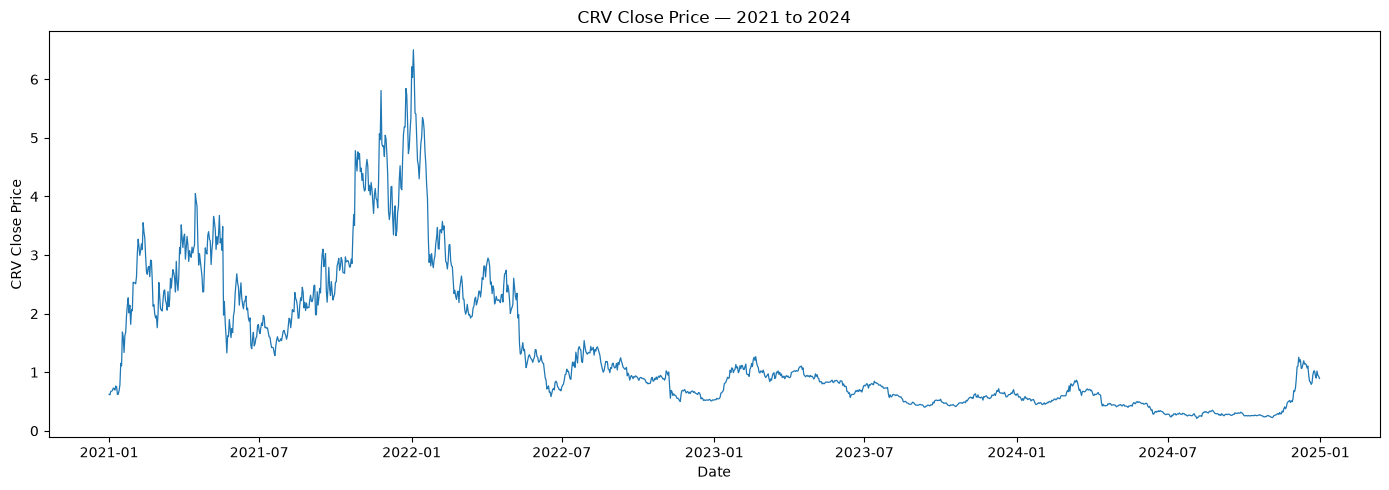

In [55]:
plt.figure(figsize=(14, 5))

plt.plot(
    crv["Date"],
    crv["CRV_Close"],
    linewidth=0.9
)

plt.title("CRV Close Price — 2021 to 2024")
plt.xlabel("Date")
plt.ylabel("CRV Close Price")

plt.tight_layout()
plt.show()

Biểu đồ là CRV Close Price từ 2021–2024, gồm 1.461 quan sát ngày. Trục Y là giá đóng cửa CRV.

Có thể chia sơ bộ thành vài giai đoạn:

2021: giá biến động mạnh, từ mức thấp tăng lên nhiều lần, sau đó liên tục dao động.
Cuối 2021 – đầu 2022: xuất hiện giai đoạn giá rất cao, đạt khoảng 6+ USD, đồng thời dao động khá mạnh.
2022: giá nhìn chung giảm và chuyển dần sang vùng thấp hơn.
2023: giá chủ yếu dao động quanh vùng khoảng 0.5–1.5 USD.
2024: tiếp tục ở mặt bằng khá thấp trong phần lớn thời gian, nhưng cuối năm có một đợt tăng rõ rệt.

Điểm quan trọng nhất là:

Mức giá trung bình và mức độ biến động của CRV thay đổi theo thời gian.

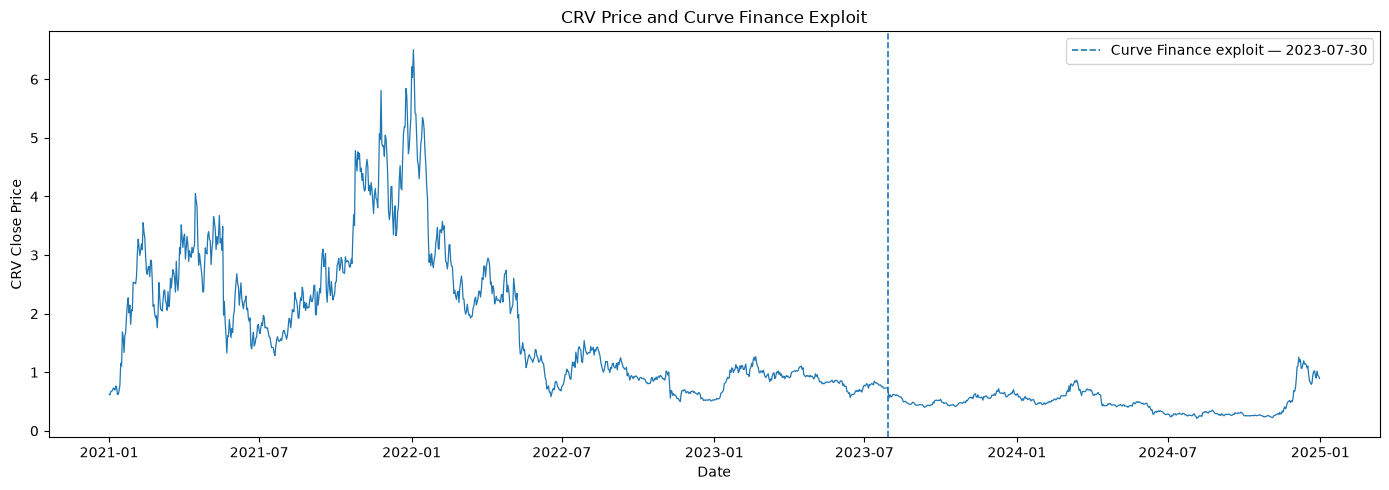

In [56]:
EVENT_DATE = pd.Timestamp("2023-07-30")

plt.figure(figsize=(14, 5))

plt.plot(
    crv["Date"],
    crv["CRV_Close"],
    linewidth=0.9
)

plt.axvline(
    EVENT_DATE,
    linestyle="--",
    linewidth=1.2,
    label="Curve Finance exploit — 2023-07-30"
)

plt.title("CRV Price and Curve Finance Exploit")
plt.xlabel("Date")
plt.ylabel("CRV Close Price")

plt.legend()

plt.tight_layout()
plt.show()

ngày 30/07/2023 nằm trong vùng giá khoảng 0.6–0.8 USD, và xung quanh đó có sự biến động nhưng không xuất hiện một cú sập cực lớn trên đồ thị giá đóng cửa giống như giai đoạn 2021–2022.

Điều này không có nghĩa là event không có tác động.

Nó chỉ cho thấy:

Nhìn trên price level của dữ liệu daily, tác động của event không quá nổi bật bằng những biến động lớn khác trong toàn bộ giai đoạn 2021–2024.

CRV có sự thay đổi rõ rệt về mặt bằng giá và mức độ biến động qua các giai đoạn 2021–2024, tạo cơ sở để kiểm tra tính dừng bằng ADF và cấu trúc tự tương quan bằng ACF.

In [57]:
crv["CRV_simple_return_check"] = (
    crv["CRV_Close"].pct_change()
)

crv["CRV_log_return_check"] = np.log(
    crv["CRV_Close"] /
    crv["CRV_Close"].shift(1)
)

crv[
    [
        "Date",
        "CRV_Close",
        "CRV_simple_return_check",
        "CRV_log_return_check"
    ]
].head(10)

,Date,CRV_Close,CRV_simple_return_check,CRV_log_return_check
0,2021-01-01,0.622334,NaN,NaN
1,2021-01-02,0.614176,-0.013109,-0.013195
2,2021-01-03,0.672281,0.094607,0.090395
3,2021-01-04,0.676984,0.006996,0.006971
4,2021-01-05,0.687015,0.014817,0.014708
5,2021-01-06,0.729665,0.062080,0.060229
6,2021-01-07,0.719132,-0.014435,-0.014541
7,2021-01-08,0.694862,-0.033749,-0.034332
8,2021-01-09,0.764276,0.099896,0.095216
9,2021-01-10,0.752120,-0.015905,-0.016033


In [58]:
comparison = pd.DataFrame({
    "simple_return_original": crv["CRV_simple_return"],
    "simple_return_check": crv["CRV_simple_return_check"],
    "log_return_original": crv["CRV_log_return"],
    "log_return_check": crv["CRV_log_return_check"],
})

comparison["simple_diff"] = (
    comparison["simple_return_original"]
    - comparison["simple_return_check"]
)

comparison["log_diff"] = (
    comparison["log_return_original"]
    - comparison["log_return_check"]
)

comparison.describe()

,simple_return_original,simple_return_check,log_return_original,log_return_check,simple_diff,log_diff
count,"1,460.000000","1,460.000000","1,460.000000","1,460.000000","1,460.000000","1,460.000000"
mean,0.002659,0.002659,0.000248,0.000248,0.000000,-0.000000
std,0.070009,0.070009,0.069406,0.069406,0.000000,0.000000
min,-0.433753,-0.433753,-0.568725,-0.568725,-0.000000,-0.000000
25%,-0.033960,-0.033960,-0.034550,-0.034550,-0.000000,-0.000000
50%,-0.001374,-0.001374,-0.001375,-0.001375,0.000000,0.000000
75%,0.033630,0.033630,0.033077,0.033077,0.000000,0.000000
max,0.522000,0.522000,0.420025,0.420025,0.000000,0.000000


In [59]:
crv["CRV_log_return"].describe()

count   1,460.000000
mean        0.000248
std         0.069406
min        -0.568725
25%        -0.034550
50%        -0.001375
75%         0.033077
max         0.420025
Name: CRV_log_return, dtype: float64

In [60]:
print("Skewness:",
      crv["CRV_log_return"].skew())

print("Kurtosis:",
      crv["CRV_log_return"].kurtosis())

Skewness: -0.09288517723401538
Kurtosis: 6.094343847613283


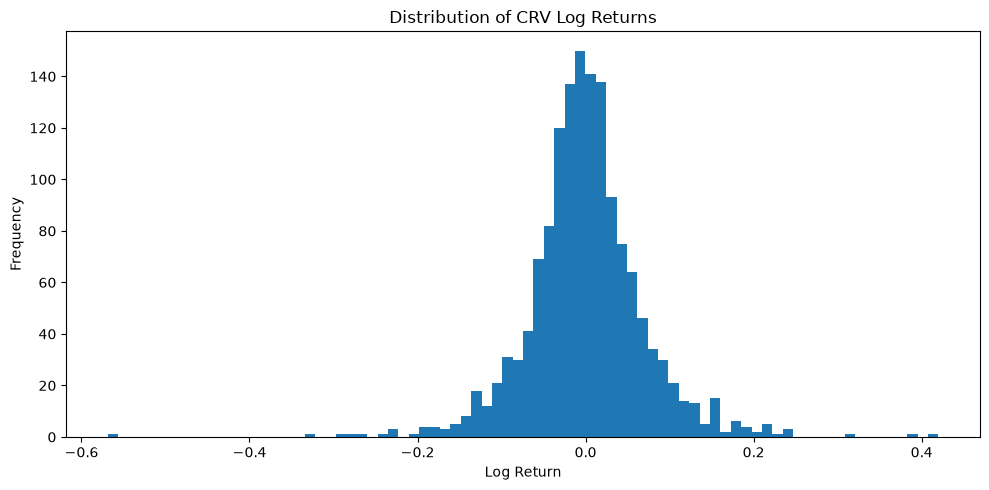

In [61]:
plt.figure(figsize=(10, 5))

plt.hist(
    crv["CRV_log_return"].dropna(),
    bins=80
)

plt.title("Distribution of CRV Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\Le Nguyen My Duyen\AppData\Local\Temp\ipykernel_8240\495710231.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


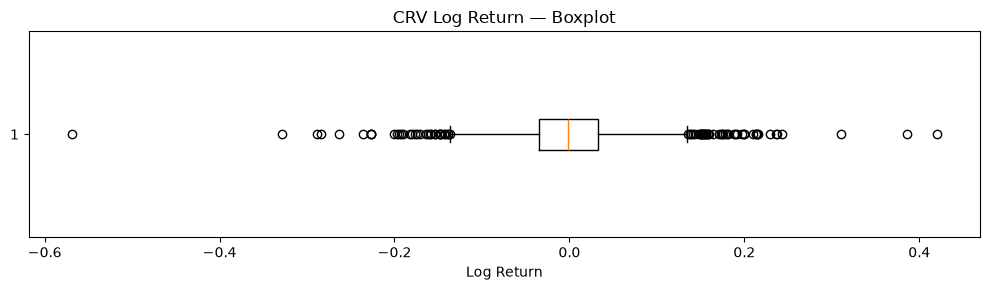

In [62]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    crv["CRV_log_return"].dropna(),
    vert=False
)

plt.title("CRV Log Return — Boxplot")
plt.xlabel("Log Return")

plt.tight_layout()
plt.show()

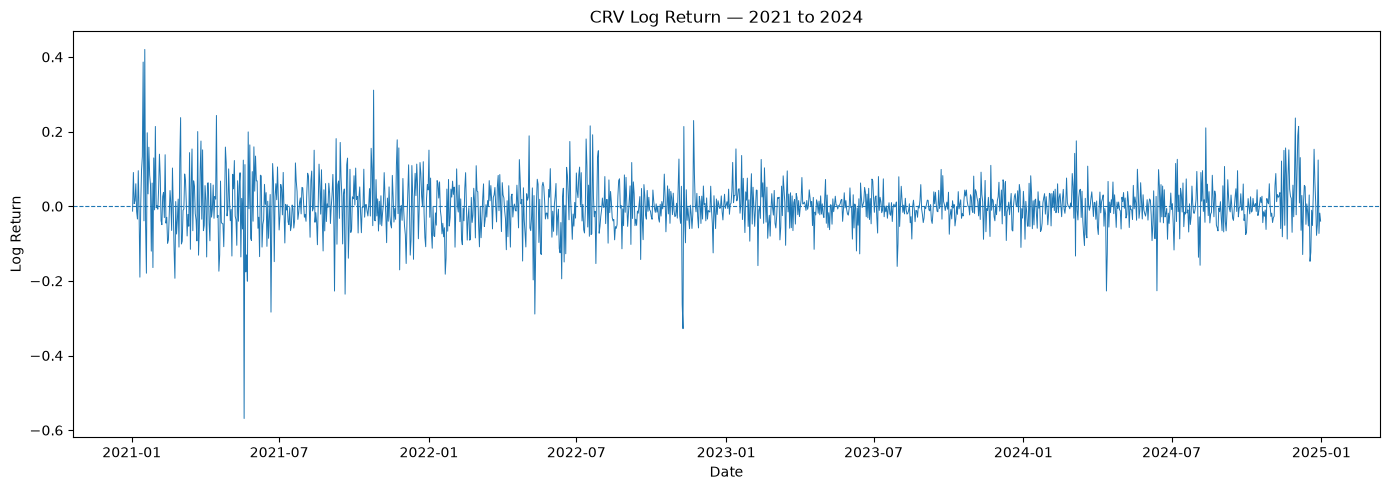

In [63]:
plt.figure(figsize=(14, 5))

plt.plot(
    crv["Date"],
    crv["CRV_log_return"],
    linewidth=0.7
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title("CRV Log Return — 2021 to 2024")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.tight_layout()
plt.show()

In [65]:
#Load S&P 500 data
sp500_path = PROCESSED_DIR / "crv_sp500_analysis.csv"

comparison = pd.read_csv(
    sp500_path,
    parse_dates=["Date"]
)

comparison = (
    comparison
    .sort_values("Date")
    .reset_index(drop=True)
)

print(f"Số dòng: {len(comparison):,}")
print(f"Số cột: {len(comparison.columns)}")

comparison.head()

Số dòng: 1,005
Số cột: 11


,Date,Open,High,Low,CRV_Close,CRV_Volume,SP500_Close,CRV_simple_return,CRV_log_return,SP500_simple_return,SP500_log_return
0,2021-01-04,0.675712,0.727619,0.583590,0.676984,95367065,"3,700.650000",NaN,NaN,NaN,NaN
1,2021-01-05,0.677240,0.724537,0.627403,0.687015,82062825,"3,726.860000",0.014817,0.014708,0.007083,0.007058
2,2021-01-06,0.687508,0.783086,0.670430,0.729665,98254303,"3,748.140000",0.062080,0.060229,0.005710,0.005694
3,2021-01-07,0.730103,0.777434,0.690804,0.719132,78180776,"3,803.790000",-0.014435,-0.014541,0.014847,0.014738
4,2021-01-08,0.717098,0.730018,0.627392,0.694862,74108158,"3,824.680000",-0.033749,-0.034332,0.005492,0.005477


In [66]:
comparison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 1005 non-null   datetime64[ns]
 1   Open                 1005 non-null   float64       
 2   High                 1005 non-null   float64       
 3   Low                  1005 non-null   float64       
 4   CRV_Close            1005 non-null   float64       
 5   CRV_Volume           1005 non-null   int64         
 6   SP500_Close          1005 non-null   float64       
 7   CRV_simple_return    1004 non-null   float64       
 8   CRV_log_return       1004 non-null   float64       
 9   SP500_simple_return  1004 non-null   float64       
 10  SP500_log_return     1004 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 86.5 KB


In [67]:
print(
    "Ngày bắt đầu:",
    comparison["Date"].min().date()
)

print(
    "Ngày kết thúc:",
    comparison["Date"].max().date()
)

print(
    "Số ngày:",
    len(comparison)
)

print(
    "Số ngày unique:",
    comparison["Date"].nunique()
)

Ngày bắt đầu: 2021-01-04
Ngày kết thúc: 2024-12-31
Số ngày: 1005
Số ngày unique: 1005


**Vẽ CRV và S&P 500**

In [68]:
comparison_plot = comparison[
    ["Date", "CRV_Close", "SP500_Close"]
].copy()

comparison_plot["CRV_index"] = (
    comparison_plot["CRV_Close"]
    / comparison_plot["CRV_Close"].iloc[0]
    * 100
)

comparison_plot["SP500_index"] = (
    comparison_plot["SP500_Close"]
    / comparison_plot["SP500_Close"].iloc[0]
    * 100
)

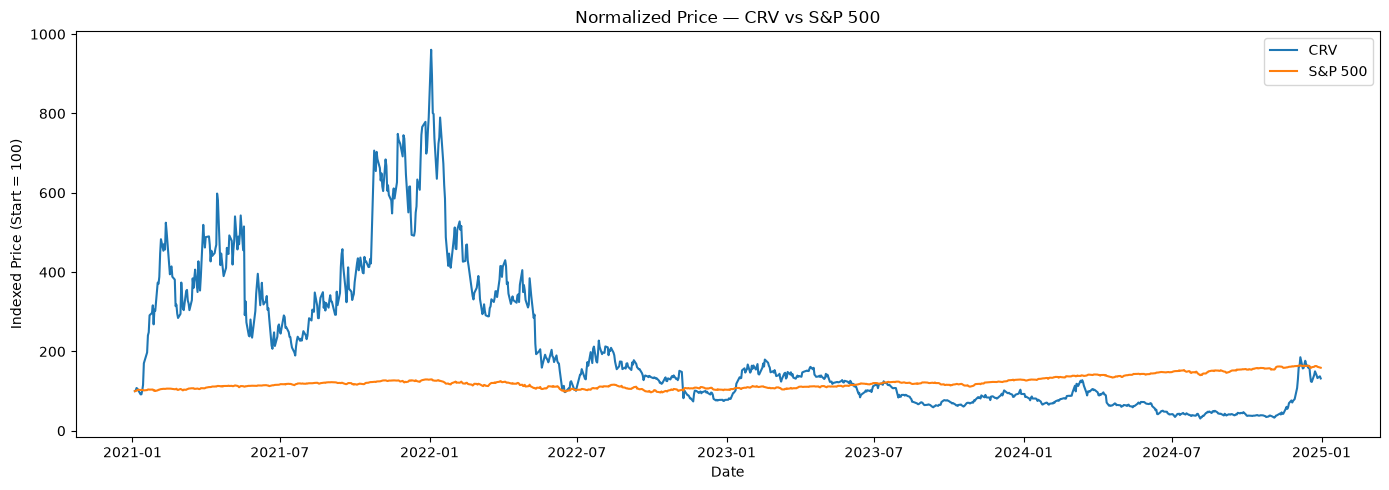

In [69]:
plt.figure(figsize=(14, 5))

plt.plot(
    comparison_plot["Date"],
    comparison_plot["CRV_index"],
    label="CRV"
)

plt.plot(
    comparison_plot["Date"],
    comparison_plot["SP500_index"],
    label="S&P 500"
)

plt.title("Normalized Price — CRV vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")

plt.legend()

plt.tight_layout()
plt.show()

**Return của CRV và S&P 500**

In [70]:
comparison[
    [
        "Date",
        "CRV_log_return",
        "SP500_log_return"
    ]
].head(10)

,Date,CRV_log_return,SP500_log_return
0,2021-01-04,NaN,NaN
1,2021-01-05,0.014708,0.007058
2,2021-01-06,0.060229,0.005694
3,2021-01-07,-0.014541,0.014738
4,2021-01-08,-0.034332,0.005477
5,2021-01-11,-0.110846,-0.006576
6,2021-01-12,0.001316,0.000416
7,2021-01-13,0.096007,0.002273
8,2021-01-14,0.133174,-0.003761
9,2021-01-15,0.386226,-0.007216


**Thống kê return hai tài sản**

In [71]:
return_summary = pd.DataFrame({
    "CRV": comparison["CRV_log_return"].describe(),
    "S&P 500": comparison["SP500_log_return"].describe()
})

return_summary

,CRV,S&P 500
count,"1,004.000000","1,004.000000"
mean,0.000276,0.000461
std,0.081947,0.010396
min,-0.568725,-0.044199
25%,-0.041727,-0.005040
50%,-0.001225,0.000731
75%,0.040171,0.006500
max,0.386226,0.053953


In [72]:
print(
    "CRV volatility:",
    comparison["CRV_log_return"].std()
)

print(
    "S&P 500 volatility:",
    comparison["SP500_log_return"].std()
)

CRV volatility: 0.0819473342179015
S&P 500 volatility: 0.010395664500591468


**Return CRV vs S&P 500**

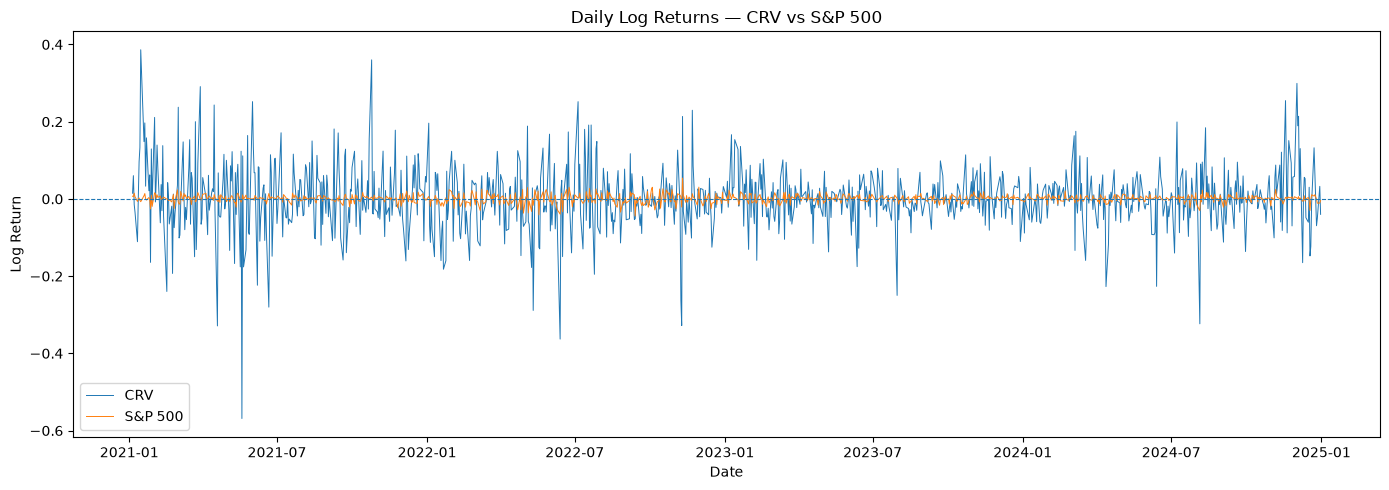

In [73]:
plt.figure(figsize=(14, 5))

plt.plot(
    comparison["Date"],
    comparison["CRV_log_return"],
    linewidth=0.7,
    label="CRV"
)

plt.plot(
    comparison["Date"],
    comparison["SP500_log_return"],
    linewidth=0.7,
    label="S&P 500"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title("Daily Log Returns — CRV vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.legend()

plt.tight_layout()
plt.show()

**Correlation sơ bộ**

In [74]:
corr = comparison[
    [
        "CRV_log_return",
        "SP500_log_return"
    ]
].corr()

corr

,CRV_log_return,SP500_log_return
CRV_log_return,1.000000,0.298062
SP500_log_return,0.298062,1.000000


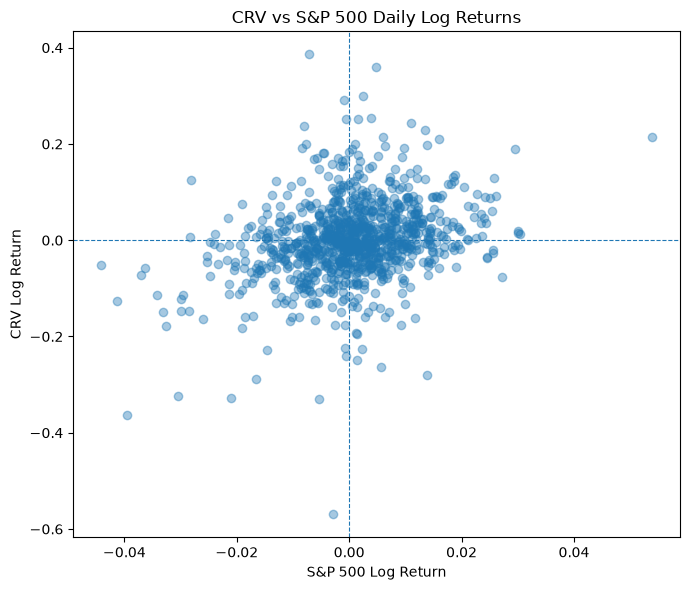

In [75]:
plt.figure(figsize=(7, 6))

plt.scatter(
    comparison["SP500_log_return"],
    comparison["CRV_log_return"],
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=0.8
)

plt.title("CRV vs S&P 500 Daily Log Returns")
plt.xlabel("S&P 500 Log Return")
plt.ylabel("CRV Log Return")

plt.tight_layout()
plt.show()

ADF sơ bộ

In [76]:
def run_adf(series, name):

    series = series.dropna()

    result = adfuller(
        series,
        autolag="AIC"
    )

    adf_stat = result[0]
    p_value = result[1]

    print(f"\n{name}")
    print("-" * 40)
    print(f"ADF statistic : {adf_stat:.6f}")
    print(f"p-value       : {p_value:.6f}")

    if p_value < 0.05:
        print(
            "→ Bác bỏ H0 ở mức ý nghĩa 5%"
        )
    else:
        print(
            "→ Không bác bỏ H0 ở mức ý nghĩa 5%"
        )

    return result

In [77]:
adf_crv_price = run_adf(
    crv["CRV_Close"],
    "CRV Price"
)

adf_crv_return = run_adf(
    crv["CRV_log_return"],
    "CRV Log Return"
)


CRV Price
----------------------------------------
ADF statistic : -2.428678
p-value       : 0.133805
→ Không bác bỏ H0 ở mức ý nghĩa 5%

CRV Log Return
----------------------------------------
ADF statistic : -39.659806
p-value       : 0.000000
→ Bác bỏ H0 ở mức ý nghĩa 5%


C:\Users\Le Nguyen My Duyen\AppData\Local\Temp\ipykernel_8240\4181164382.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
C:\Users\Le Nguyen My Duyen\AppData\Local\Temp\ipykernel_8240\4181164382.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(


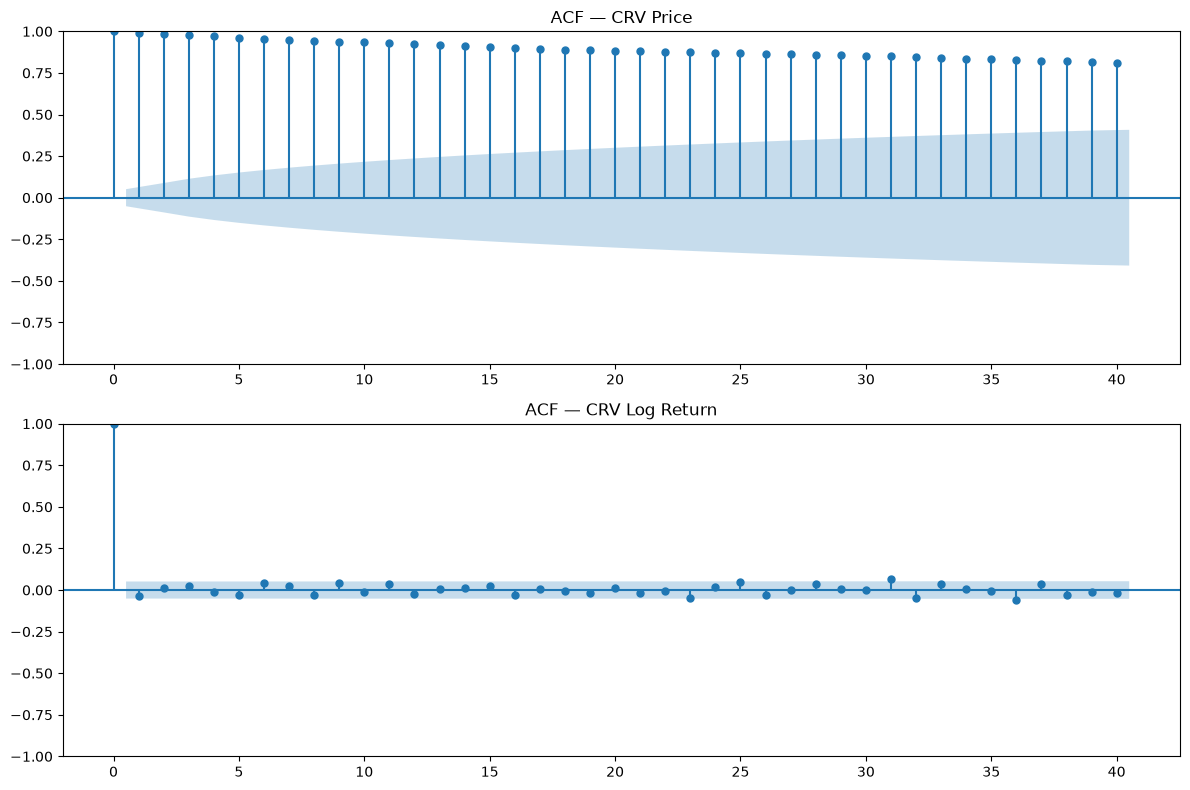

In [78]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8)
)

plot_acf(
    crv["CRV_Close"].dropna(),
    lags=40,
    ax=axes[0]
)

axes[0].set_title(
    "ACF — CRV Price"
)

plot_acf(
    crv["CRV_log_return"].dropna(),
    lags=40,
    ax=axes[1]
)

axes[1].set_title(
    "ACF — CRV Log Return"
)

plt.tight_layout()
plt.show()

In [79]:
readiness = pd.DataFrame({
    "Check": [
        "Date hợp lệ",
        "Duplicate Date",
        "Missing values",
        "Calendar-day gap",
        "CRV price > 0",
        "Event date 30/07/2023",
        "Có return",
        "Có benchmark S&P 500"
    ],

    "Result": [
        crv["Date"].notna().all(),
        crv["Date"].duplicated().sum() == 0,
        crv.isna().sum().sum() == 0,
        len(missing_dates) == 0,
        (crv["CRV_Close"] > 0).all(),
        EVENT_DATE in set(crv["Date"]),
        "CRV_log_return" in crv.columns,
        "SP500_Close" in comparison.columns
    ]
})

readiness

,Check,Result
0,Date hợp lệ,True
1,Duplicate Date,True
2,Missing values,False
3,Calendar-day gap,True
4,CRV price > 0,True
5,Event date 30/07/2023,True
6,Có return,True
7,Có benchmark S&P 500,True


Insight: Dữ liệu cho thấy giá CRV có đặc tính không dừng, thể hiện qua mức tự tương quan cao và kết quả ADF không bác bỏ giả thuyết về unit root (p-value = 0.1338). Khi chuyển sang log return, chuỗi trở nên dừng với p-value < 0.001 và ACF chủ yếu dao động quanh 0. Điều này cho thấy giá CRV có tính phụ thuộc theo thời gian mạnh, trong khi biến động giá theo ngày phù hợp hơn cho các phân tích thống kê tiếp theo. Ngoài ra, dữ liệu CRV có thể được đối chiếu với S&P 500 để xem xét mức độ đồng biến giữa tài sản crypto và thị trường truyền thống; hệ số tương quan log return khoảng 0.298, cho thấy có mối liên hệ dương nhưng không hoàn toàn đồng biến.

CRV Price không dừng trong giai đoạn 2021–2024, trong khi CRV Log Return có tính dừng. Kết quả cho thấy việc sử dụng return thay cho price là phù hợp hơn cho các phân tích chuỗi thời gian tiếp theo. Bên cạnh đó, CRV có tương quan dương ở mức vừa phải với S&P 500 (≈ 0.298), gợi ý rằng CRV có một phần biến động cùng chiều với thị trường truyền thống nhưng vẫn có những đặc điểm biến động riêng.